            Date Country  Confirmed  Deaths  Recovered  Active
97383 2020-01-01     USA      16752    3563      83369       0
54821 2020-01-01   Italy      53885    2598     361845       0
6566  2020-01-01      UK     441076   17172      15730  408174
37081 2020-01-01      UK     446982    5790     112603  328589
76596 2020-01-01   China     454675    6920     239964  207791
Total Confirmed: 24995164233
Total Deaths: 998495659
Total Recovered: 20042348667
Country
USA        499998
Spain      499995
India      499991
China      499982
Italy      499980
UK         499963
Russia     499950
Germany    499944
Brazil     499934
France     499861
Name: Confirmed, dtype: int64


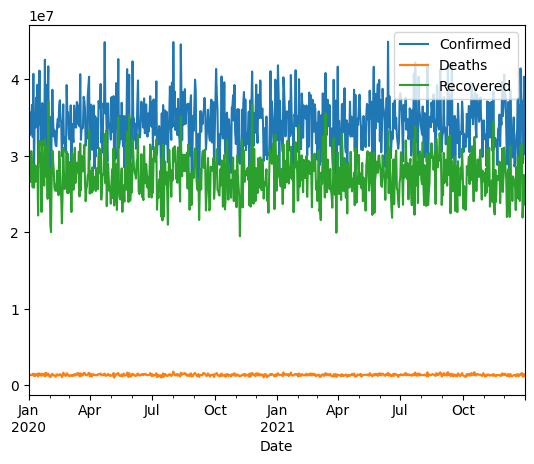

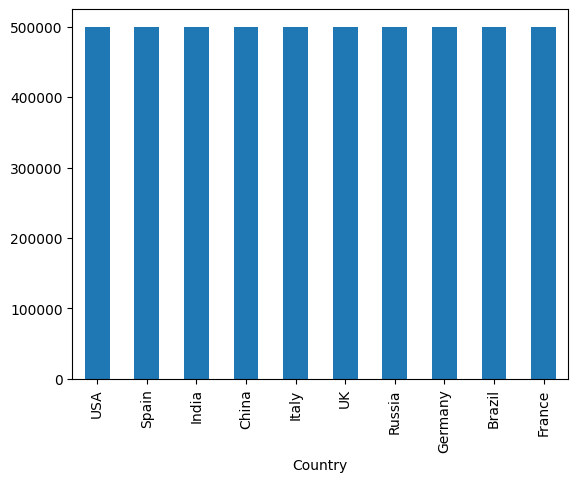

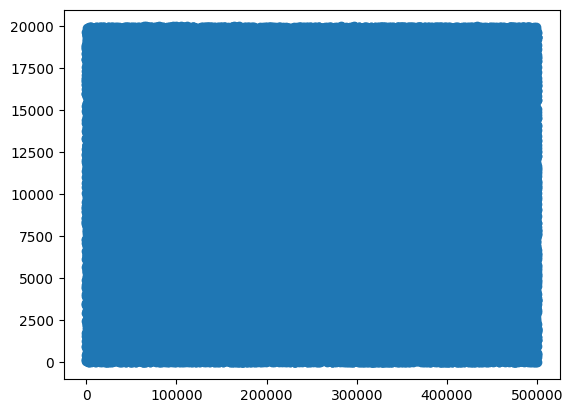

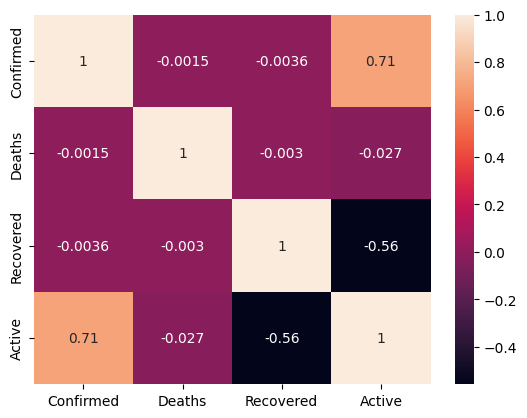

ModuleNotFoundError: No module named 'jupyter_dash'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n=100000

dates=pd.date_range(start="2020-01-01",end="2021-12-31")
countries=["India","USA","Brazil","UK","Russia","France","Italy","Germany","Spain","China"]

data={
"Date":np.random.choice(dates,n),
"Country":np.random.choice(countries,n),
"Confirmed":np.random.randint(0,500000,n),
"Deaths":np.random.randint(0,20000,n),
"Recovered":np.random.randint(0,400000,n)
}

df=pd.DataFrame(data)

df["Active"]=df["Confirmed"]-df["Deaths"]-df["Recovered"]
df["Active"]=df["Active"].clip(lower=0)

df=df.drop_duplicates().dropna()

df["Date"]=pd.to_datetime(df["Date"])
df=df.sort_values("Date")

print(df.head())

print("Total Confirmed:",df["Confirmed"].sum())
print("Total Deaths:",df["Deaths"].sum())
print("Total Recovered:",df["Recovered"].sum())

top=df.groupby("Country")["Confirmed"].max().sort_values(ascending=False).head(10)
print(top)

global_trend=df.groupby("Date")[["Confirmed","Deaths","Recovered"]].sum()

global_trend.plot()
plt.show()

top.plot(kind="bar")
plt.show()

plt.scatter(df["Confirmed"],df["Deaths"])
plt.show()

sns.heatmap(df[["Confirmed","Deaths","Recovered","Active"]].corr(),annot=True)
plt.show()

from jupyter_dash import JupyterDash
from dash import dcc,html
from dash.dependencies import Input,Output
import plotly.express as px

app=JupyterDash(__name__)

countries=sorted(df["Country"].unique())

app.layout=html.Div([
html.H1("COVID-19 Dashboard"),
dcc.Dropdown(id="country",options=[{"label":c,"value":c} for c in countries],value="India"),
dcc.Graph(id="line_chart")
])

@app.callback(Output("line_chart","figure"),Input("country","value"))
def update_graph(country):
    dff=df[df["Country"]==country].groupby("Date")[["Confirmed"]].sum().reset_index()
    return px.line(dff,x="Date",y="Confirmed")

app.run(debug=True)